# FSO Fog Classifier — MobileNetV2 for Free Space Optics Power Control

**Project:** Free Space Optics (FSO) communication system  
**Problem:** FSO links transmit data through light beams. Fog scatters light and degrades the signal. This classifier detects atmospheric fog conditions in real-time from a camera image so the transmitter can automatically boost power.

**Model:** MobileNetV2 (ImageNet pretrained) fine-tuned for 3-class visibility classification  
**Classes:** `CLEAR` | `MEDIUM_FOG` | `HEAVY_FOG`  
**Dataset:** Foggy Cityscapes — 1,500 images (500 per class)  
**Deployment target:** Raspberry Pi 4 via ONNX Runtime

```

In [19]:
!pip install -q torch torchvision seaborn scikit-learn

In [20]:
import os
import sys
import json
import math
import random
import shutil
import time
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Tuple, Callable

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch import Tensor
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.10.0+cpu


# Dataset setup

In [21]:
KAGGLE_INPUT = Path("/kaggle/input")                                                                                                                       
WORKING_DIR  = Path("/kaggle/working")      

RAW_DIR = KAGGLE_INPUT / "datasets/yessicatuteja/foggy-cityscapes-image-dataset/Foggy_Cityscapes"                                                        
RESIDE_OUTDOOR = KAGGLE_INPUT / "datasets/balraj98/synthetic-objective-testing-set-sots-reside/outdoor"

assert RAW_DIR.exists(), f"Not found: {RAW_DIR}"
print(f"Foggy Cityscapes: {RAW_DIR}")
print("\nFolders inside:")
for item in sorted(RAW_DIR.iterdir()):
   if item.is_dir():
       count = len([f for f in item.rglob("*") if f.is_file()])
       print(f"  {item.name}/  ({count} images)")
                                                                                                                                                                  

Foggy Cityscapes: /kaggle/input/datasets/yessicatuteja/foggy-cityscapes-image-dataset/Foggy_Cityscapes

Folders inside:
  Dense_Fog/  (500 images)
  Medium_Fog/  (500 images)
  No_Fog/  (500 images)


# Mapping and exploration

In [22]:

FOLDER_MAP = {
    "No_Fog":     "clear",
    "Medium_Fog": "medium_fog",
    "Dense_Fog":  "heavy_fog",
}

PROCESSED_DIR = WORKING_DIR / "data" / "processed"
SPLITS = ["train", "val", "test"]
CLASS_NAMES = ["clear", "medium_fog", "heavy_fog"]
TRAIN_RATIO, VAL_RATIO = 0.70, 0.15  # 70/15/15

def prepare_splits(raw_dir: Path, processed_dir: Path, folder_map: dict,
                   train_ratio: float = 0.70, val_ratio: float = 0.15,
                   seed: int = 42) -> None:
    """Copy images from raw dataset folders into train/val/test splits."""
    rng = random.Random(seed)

    for raw_name, class_name in folder_map.items():
        src = raw_dir / raw_name
        if not src.exists():
            print(f"WARNING: {src} not found — skipping")
            continue

        images = sorted([p for p in src.iterdir()
                         if p.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp")])
        rng.shuffle(images)

        n = len(images)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)

        splits = {
            "train": images[:n_train],
            "val":   images[n_train:n_train + n_val],
            "test":  images[n_train + n_val:],
        }

        for split_name, split_images in splits.items():
            dest = processed_dir / split_name / class_name
            dest.mkdir(parents=True, exist_ok=True)
            for img in split_images:
                shutil.copy2(img, dest / img.name)

        print(f"{class_name:12s}: {len(splits['train'])} train | "
              f"{len(splits['val'])} val | {len(splits['test'])} test")


prepare_splits(RAW_DIR, PROCESSED_DIR, FOLDER_MAP)
print("\nDataset ready at:", PROCESSED_DIR)

clear       : 350 train | 75 val | 75 test
medium_fog  : 350 train | 75 val | 75 test
heavy_fog   : 350 train | 75 val | 75 test

Dataset ready at: /kaggle/working/data/processed


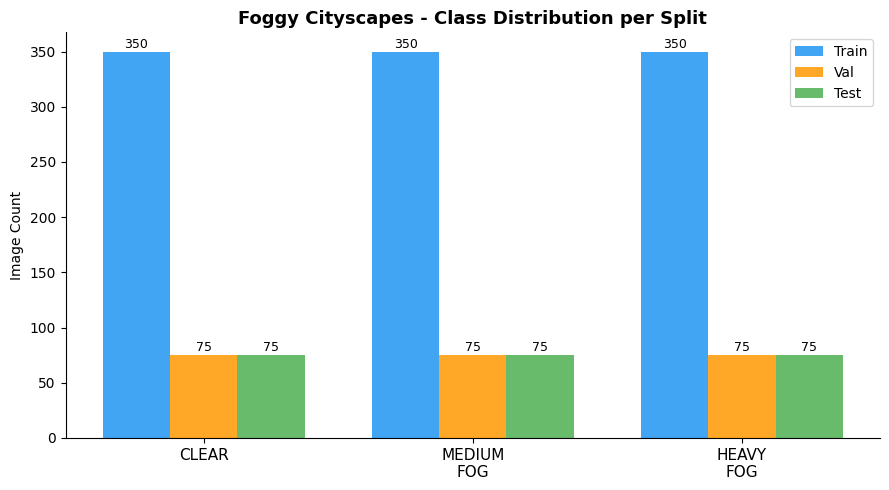

In [23]:
# Class distribution bar chart
split_counts = {}
for split in SPLITS:
    counts = {}
    for cls in CLASS_NAMES:
        cls_dir = PROCESSED_DIR / split / cls
        counts[cls] = len(list(cls_dir.glob("*"))) if cls_dir.exists() else 0
    split_counts[split] = counts

x = np.arange(len(CLASS_NAMES))
width = 0.25
colors = ["#2196F3", "#FF9800", "#4CAF50"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (split, color) in enumerate(zip(SPLITS, colors)):
    vals = [split_counts[split][c] for c in CLASS_NAMES]
    bars = ax.bar(x + i * width, vals, width, label=split.capitalize(), color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                str(v), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels([c.replace("_", "\n").upper() for c in CLASS_NAMES], fontsize=11)
ax.set_ylabel("Image Count")
ax.set_title("Foggy Cityscapes - Class Distribution per Split", fontsize=13, fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

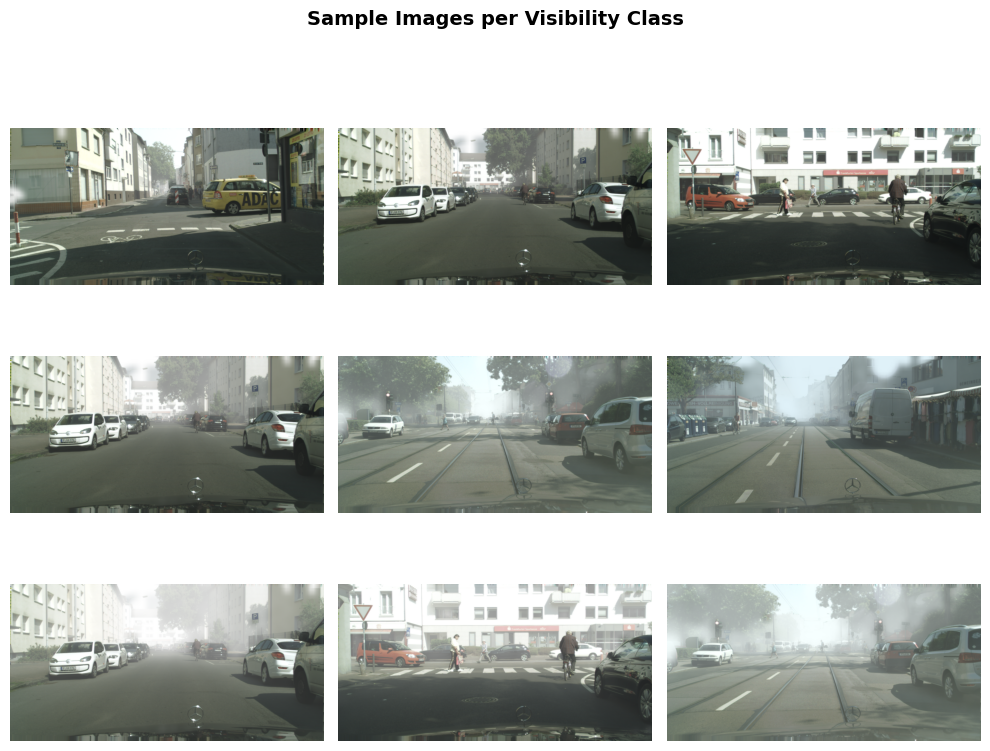

In [24]:
CLASS_COLORS = {"clear": "#4CAF50", "medium_fog": "#FF9800", "heavy_fog": "#F44336"}
CLASS_LABELS = {"clear": "CLEAR", "medium_fog": "MEDIUM FOG", "heavy_fog": "HEAVY FOG"}
SAMPLES_PER_CLASS = 3

fig, axes = plt.subplots(3, SAMPLES_PER_CLASS, figsize=(10, 8))
fig.suptitle("Sample Images per Visibility Class", fontsize=14, fontweight="bold", y=1.01)

for row, cls in enumerate(CLASS_NAMES):
    cls_dir = PROCESSED_DIR / "train" / cls
    images = sorted(cls_dir.glob("*"))[:SAMPLES_PER_CLASS]
    for col, img_path in enumerate(images):
        ax = axes[row][col]
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(CLASS_LABELS[cls], fontsize=11, fontweight="bold",
                          color=CLASS_COLORS[cls], rotation=90, labelpad=8)
            ax.yaxis.set_label_position("left")
            ax.tick_params(left=False)

plt.tight_layout()
plt.show()

## Synthetic Fog Augmentation Preview

During training, we apply the **Koschmieder atmospheric scattering model** to synthetically augment clear images with fog. This helps the model generalise to fog densities not represented in the dataset.

$$I(x) = J(x) \cdot t(x) + A \cdot (1 - t(x))$$

where $t(x) = e^{-\beta \cdot d(x)}$, $\beta$ is the scattering coefficient, and $d(x)$ is estimated depth.

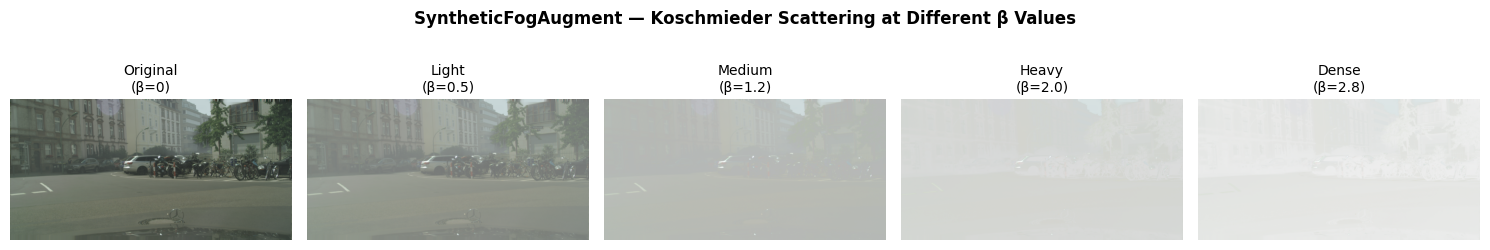

In [25]:
class SyntheticFogAugment:
    """Koschmieder atmospheric scattering model for synthetic fog."""

    def __init__(self, beta_range: Tuple[float, float] = (0.5, 2.5),
                 A: float = 1.0, p: float = 1.0) -> None:
        self.beta_range = beta_range
        self.A = float(A)
        self.p = p

    def __call__(self, img: Image.Image, beta: Optional[float] = None) -> Image.Image:
        if random.random() > self.p:
            return img
        img_np = np.array(img, dtype=np.float32) / 255.0
        luminance = (0.299 * img_np[:,:,0] + 0.587 * img_np[:,:,1] + 0.114 * img_np[:,:,2])
        lum_min, lum_max = luminance.min(), luminance.max()
        lum_norm = (luminance - lum_min) / (lum_max - lum_min + 1e-6)
        depth_map = 1.0 - lum_norm
        if beta is None:
            beta = random.uniform(self.beta_range[0], self.beta_range[1])
        transmission = np.exp(-beta * depth_map)[:, :, np.newaxis]
        fogged = img_np * transmission + self.A * (1.0 - transmission)
        return Image.fromarray((np.clip(fogged, 0, 1) * 255).astype(np.uint8))


aug = SyntheticFogAugment(p=1.0)
sample_img_path = next((PROCESSED_DIR / "train" / "clear").glob("*"))
original = Image.open(sample_img_path).convert("RGB")

beta_values = [0.0, 0.5, 1.2, 2.0, 2.8]
labels = ["Original\n(β=0)", "Light\n(β=0.5)", "Medium\n(β=1.2)", "Heavy\n(β=2.0)", "Dense\n(β=2.8)"]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("SyntheticFogAugment — Koschmieder Scattering at Different β Values",
             fontsize=12, fontweight="bold")

for ax, beta, label in zip(axes, beta_values, labels):
    if beta == 0.0:
        img_show = original
    else:
        img_show = aug(original, beta=beta)
    ax.imshow(img_show)
    ax.set_title(label, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Model Architecture - FogClassifier (MobileNetV2)

In [27]:
CLASS_LABEL_NAMES = ["CLEAR", "MEDIUM_FOG", "HEAVY_FOG"]


@dataclass
class FogClassifierOutput:
    logits: Tensor
    probabilities: Tensor
    predicted_class: int
    confidence: float
    class_label: str


class FogClassifier(nn.Module):
    """
    MobileNetV2 backbone + custom dropout head for fog visibility classification.
    """

    def __init__(self, num_classes: int = 3, dropout: float = 0.3,
                 pretrained: bool = True) -> None:
        super().__init__()
        weights = MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = mobilenet_v2(weights=weights)
        self.features   = backbone.features
        self.pool       = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(1280, num_classes),
        )
        self.num_classes  = num_classes
        self._class_names = CLASS_LABEL_NAMES[:num_classes]

    def forward(self, x: Tensor) -> Tensor:
        return self.classifier(torch.flatten(self.pool(self.features(x)), 1))

    def predict(self, x: Tensor) -> FogClassifierOutput:
        was_training = self.training
        self.eval()
        with torch.no_grad():
            logits = self.forward(x)
            probs  = torch.softmax(logits, dim=-1)
            pred   = int(torch.argmax(probs[0]).item())
        if was_training:
            self.train()
        return FogClassifierOutput(logits, probs, pred,
                                   float(probs[0][pred].item()),
                                   self._class_names[pred])

    def freeze_backbone(self):
        for p in self.features.parameters(): p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.features.parameters(): p.requires_grad = True

    def count_parameters(self) -> dict:
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return {"total": total, "trainable": trainable}


# Inspect architecture
model = FogClassifier(num_classes=3, dropout=0.3, pretrained=True).to(DEVICE)
params = model.count_parameters()
print(f"Total parameters    : {params['total']:,}")
print(f"Trainable (Phase A) : {params['trainable']:,}  (head only)")
model.unfreeze_backbone()
params_b = model.count_parameters()
print(f"Trainable (Phase B) : {params_b['trainable']:,}  (all layers)")
model.freeze_backbone()  # reset for training

# Quick shape check
dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
out   = model(dummy)
print(f"\nInput shape : {tuple(dummy.shape)}")
print(f"Output shape: {tuple(out.shape)}  ← logits for 3 classes")

Total parameters    : 2,227,715
Trainable (Phase A) : 2,227,715  (head only)
Trainable (Phase B) : 2,227,715  (all layers)

Input shape : (2, 3, 224, 224)
Output shape: (2, 3)  ← logits for 3 classes


In [28]:
CLASS_TO_IDX = {"clear": 0, "medium_fog": 1, "heavy_fog": 2}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
_VALID_EXT   = (".jpg", ".jpeg", ".png", ".bmp")


class FogDataset(Dataset):
    """Loads images from clear/ medium_fog/ heavy_fog/ sub-directories."""

    def __init__(self, root: Path, transform: Optional[Callable] = None) -> None:
        root = Path(root)
        if not root.exists():
            raise FileNotFoundError(f"Dataset root not found: {root}")
        self.root      = root
        self.transform = transform
        self._samples: list[tuple[Path, int]] = []
        for cls, idx in CLASS_TO_IDX.items():
            cls_dir = root / cls
            if not cls_dir.exists():
                continue
            for p in sorted(cls_dir.iterdir()):
                if p.suffix.lower() in _VALID_EXT:
                    self._samples.append((p, idx))
        if not self._samples:
            raise RuntimeError(f"No images found in {root}")

    def __len__(self): return len(self._samples)

    def __getitem__(self, idx):
        path, label = self._samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

    def get_class_weights(self) -> Tensor:
        counts = torch.zeros(3, dtype=torch.float)
        for _, lbl in self._samples: counts[lbl] += 1
        total = counts.sum()
        return torch.tensor([total / (3 * c) if c > 0 else 0.0 for c in counts])

    def class_distribution(self) -> dict:
        dist = {c: 0 for c in CLASS_TO_IDX}
        for _, lbl in self._samples: dist[IDX_TO_CLASS[lbl]] += 1
        return dist


# Transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    SyntheticFogAugment(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfm = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Datasets & DataLoaders 
BATCH_SIZE   = 32
NUM_WORKERS  = 2

train_ds = FogDataset(PROCESSED_DIR / "train", transform=train_tfm)
val_ds   = FogDataset(PROCESSED_DIR / "val",   transform=val_tfm)
test_ds  = FogDataset(PROCESSED_DIR / "test",  transform=val_tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)

class_weights = train_ds.get_class_weights().to(DEVICE)
print(f"Train   : {len(train_ds):4d} images  | {len(train_loader)} batches")
print(f"Val     : {len(val_ds):4d} images  | {len(val_loader)} batches")
print(f"Test    : {len(test_ds):4d} images  | {len(test_loader)} batches")
print(f"Class weights: {class_weights.tolist()}")

Train   : 1050 images  | 33 batches
Val     :  225 images  | 8 batches
Test    :  225 images  | 8 batches
Class weights: [1.0, 1.0, 1.0]


# Training

In [32]:
def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 1e-4,
                 ckpt_path: Optional[Path] = None):
        self.patience   = patience
        self.min_delta  = min_delta
        self.ckpt_path  = ckpt_path
        self.best_loss  = float("inf")
        self.counter    = 0
        self.triggered  = False

    def step(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            if self.ckpt_path:
                self.ckpt_path.parent.mkdir(parents=True, exist_ok=True)
                torch.save(model.state_dict(), self.ckpt_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
        return self.triggered


def run_epoch(model, loader, criterion, device, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / max(total, 1), correct / max(total, 1)

In [33]:
PHASE_A_EPOCHS  = 5
PHASE_B_EPOCHS  = 15
PHASE_A_LR      = 1e-3
PHASE_B_LR      = 1e-4
WEIGHT_DECAY    = 1e-4
PATIENCE        = 5
CKPT_PATH       = WORKING_DIR / "checkpoints" / "fog_classifier_best.pt"

set_seed(42)
model     = FogClassifier(num_classes=3, dropout=0.3, pretrained=True).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
history   = []

# Phase A — frozen backbone, train head only
print("=" * 60)
print(f"PHASE A — Head only  ({PHASE_A_EPOCHS} epochs, lr={PHASE_A_LR})")
print("=" * 60)

model.freeze_backbone()
opt_a   = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                lr=PHASE_A_LR, weight_decay=WEIGHT_DECAY)
sched_a = CosineAnnealingLR(opt_a, T_max=PHASE_A_EPOCHS)
stopper = EarlyStopping(patience=PATIENCE, ckpt_path=CKPT_PATH)

for epoch in range(1, PHASE_A_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, DEVICE, opt_a)
    vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, DEVICE)
    sched_a.step()
    history.append({"phase": "A", "epoch": epoch,
                    "train_loss": tr_loss, "train_acc": tr_acc,
                    "val_loss":   vl_loss, "val_acc":   vl_acc})
    print(f"A | {epoch:02d}/{PHASE_A_EPOCHS}  "
          f"train loss={tr_loss:.4f} acc={tr_acc:.3f}  "
          f"val loss={vl_loss:.4f} acc={vl_acc:.3f}  "
          f"({time.time()-t0:.1f}s)")
    if stopper.step(vl_loss, model):
        print("Early stopping (Phase A).")
        break

print()
print("=" * 60)
print(f"PHASE B — Full fine-tune  ({PHASE_B_EPOCHS} epochs, lr={PHASE_B_LR})")
print("=" * 60)

if CKPT_PATH.exists():
    model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
    print("Loaded Phase A best weights.")

model.unfreeze_backbone()
opt_b   = AdamW(model.parameters(), lr=PHASE_B_LR, weight_decay=WEIGHT_DECAY)
sched_b = CosineAnnealingLR(opt_b, T_max=PHASE_B_EPOCHS)
stopper = EarlyStopping(patience=PATIENCE, ckpt_path=CKPT_PATH)

for epoch in range(1, PHASE_B_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, DEVICE, opt_b)
    vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, DEVICE)
    sched_b.step()
    history.append({"phase": "B", "epoch": epoch,
                    "train_loss": tr_loss, "train_acc": tr_acc,
                    "val_loss":   vl_loss, "val_acc":   vl_acc})
    print(f"B | {epoch:02d}/{PHASE_B_EPOCHS}  "
          f"train loss={tr_loss:.4f} acc={tr_acc:.3f}  "
          f"val loss={vl_loss:.4f} acc={vl_acc:.3f}  "
          f"({time.time()-t0:.1f}s)")
    if stopper.step(vl_loss, model):
        print("Early stopping (Phase B)."); break

print(f"\nBest checkpoint saved → {CKPT_PATH}")

PHASE A — Head only  (5 epochs, lr=0.001)
A | 01/5  train loss=1.1421 acc=0.362  val loss=1.0528 acc=0.418  (94.3s)
A | 02/5  train loss=1.0186 acc=0.461  val loss=0.9836 acc=0.480  (92.6s)
A | 03/5  train loss=0.9902 acc=0.490  val loss=0.9891 acc=0.471  (91.5s)
A | 04/5  train loss=0.9579 acc=0.521  val loss=0.9631 acc=0.476  (109.7s)
A | 05/5  train loss=0.9610 acc=0.525  val loss=0.9349 acc=0.498  (91.0s)

PHASE B — Full fine-tune  (15 epochs, lr=0.0001)
Loaded Phase A best weights.
B | 01/15  train loss=0.8502 acc=0.579  val loss=0.5837 acc=0.756  (143.3s)
B | 02/15  train loss=0.7035 acc=0.682  val loss=0.4671 acc=0.844  (150.8s)
B | 03/15  train loss=0.5927 acc=0.750  val loss=0.4370 acc=0.822  (152.9s)
B | 04/15  train loss=0.5736 acc=0.744  val loss=0.3692 acc=0.858  (172.0s)
B | 05/15  train loss=0.4727 acc=0.792  val loss=0.3301 acc=0.867  (155.7s)
B | 06/15  train loss=0.4594 acc=0.790  val loss=0.2585 acc=0.902  (149.9s)
B | 07/15  train loss=0.4478 acc=0.803  val loss=0.2

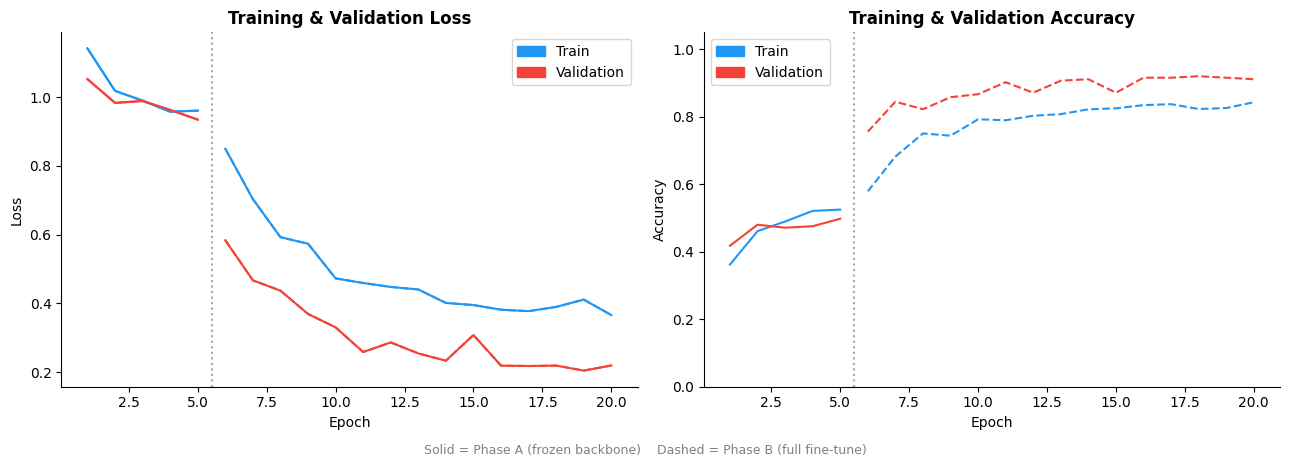

In [34]:
phase_a = [h for h in history if h["phase"] == "A"]
phase_b = [h for h in history if h["phase"] == "B"]

a_epochs = [h["epoch"]      for h in phase_a]
b_epochs = [h["epoch"] + len(phase_a) for h in phase_b]
all_epochs = a_epochs + b_epochs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Loss ──────────────────────────────────────────────────────────────────────
for (epochs, data, label, ls) in [
    (a_epochs, phase_a, "Phase A", "-"),
    (b_epochs, phase_b, "Phase B", "-"),
]:
    ax1.plot(epochs, [h["train_loss"] for h in data],
             ls, color="#2196F3", label=f"Train {label}" if label=="Phase A" else "_")
    ax1.plot(epochs, [h["val_loss"]   for h in data],
             ls, color="#F44336", label=f"Val {label}"   if label=="Phase A" else "_")

ax1.plot(a_epochs, [h["train_loss"] for h in phase_a], "-", color="#2196F3")
ax1.plot(b_epochs, [h["train_loss"] for h in phase_b], "--", color="#2196F3")
ax1.plot(a_epochs, [h["val_loss"]   for h in phase_a], "-", color="#F44336")
ax1.plot(b_epochs, [h["val_loss"]   for h in phase_b], "--", color="#F44336")

if a_epochs and b_epochs:
    ax1.axvline(x=len(a_epochs) + 0.5, color="gray", linestyle=":", alpha=0.7, label="Phase A→B")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training & Validation Loss", fontweight="bold")
patch_tr  = mpatches.Patch(color="#2196F3", label="Train")
patch_val = mpatches.Patch(color="#F44336", label="Validation")
ax1.legend(handles=[patch_tr, patch_val])
ax1.spines[["top", "right"]].set_visible(False)

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax2.plot(a_epochs, [h["train_acc"] for h in phase_a], "-",  color="#2196F3")
ax2.plot(b_epochs, [h["train_acc"] for h in phase_b], "--", color="#2196F3")
ax2.plot(a_epochs, [h["val_acc"]   for h in phase_a], "-",  color="#F44336")
ax2.plot(b_epochs, [h["val_acc"]   for h in phase_b], "--", color="#F44336")
if a_epochs and b_epochs:
    ax2.axvline(x=len(a_epochs) + 0.5, color="gray", linestyle=":", alpha=0.7)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1.05)
ax2.set_title("Training & Validation Accuracy", fontweight="bold")
ax2.legend(handles=[patch_tr, patch_val])
ax2.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.02, "Solid = Phase A (frozen backbone)    Dashed = Phase B (full fine-tune)",
         ha="center", fontsize=9, color="gray")
plt.tight_layout()
plt.savefig(WORKING_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
best_model = FogClassifier(num_classes=3, pretrained=False).to(DEVICE)
best_model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = best_model(imgs).argmax(1).cpu().numpy().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy().tolist())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

n_classes = 3
cm = np.zeros((n_classes, n_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t][p] += 1

accuracy = np.trace(cm) / cm.sum()
per_class_metrics = {}
f1_scores = []

for c in range(n_classes):
    tp = cm[c, c]
    fp = cm[:, c].sum() - tp
    fn = cm[c, :].sum() - tp
    prec  = tp / max(tp + fp, 1)
    rec   = tp / max(tp + fn, 1)
    f1    = 2 * prec * rec / max(prec + rec, 1e-9)
    f1_scores.append(f1)
    per_class_metrics[CLASS_LABEL_NAMES[c]] = {"precision": prec, "recall": rec,
                                                "f1": f1, "support": int(cm[c].sum())}

macro_f1 = np.mean(f1_scores)

sep = "-" * 60
print(f"\n{sep}")
print("  TEST SET RESULTS")
print(sep)
print(f"  Samples   : {len(y_true)}")
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  Macro F1  : {macro_f1:.4f}")
print(sep)
print(f"  {'Class':<14} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
print(sep)
for cls, m in per_class_metrics.items():
    print(f"  {cls:<14} {m['precision']:>10.4f} {m['recall']:>8.4f} {m['f1']:>8.4f} {m['support']:>9}")



------------------------------------------------------------
  TEST SET RESULTS
------------------------------------------------------------
  Samples   : 225
  Accuracy  : 0.9289  (92.9%)
  Macro F1  : 0.9293
------------------------------------------------------------
  Class           Precision   Recall       F1   Support
------------------------------------------------------------
  CLEAR              0.8974   0.9333   0.9150        75
  MEDIUM_FOG         0.8933   0.8933   0.8933        75
  HEAVY_FOG          1.0000   0.9600   0.9796        75


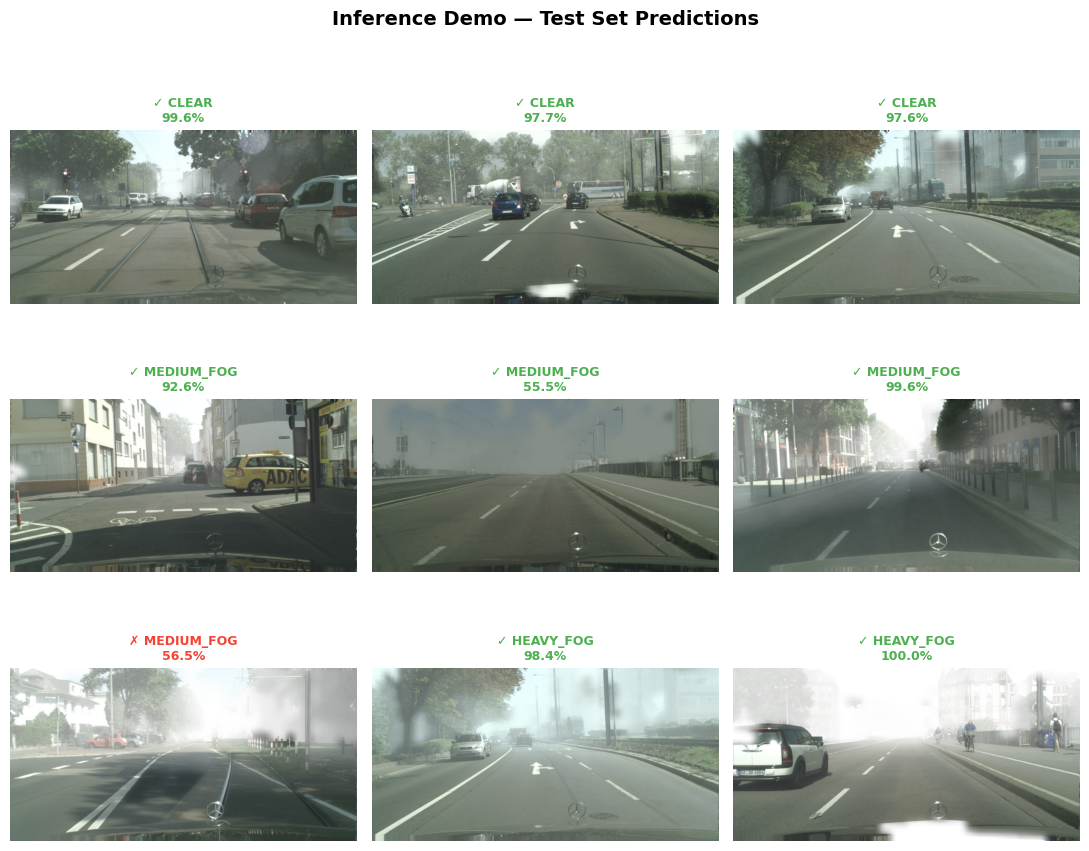

In [36]:
CLASS_COLORS = {"CLEAR": "#4CAF50", "MEDIUM_FOG": "#FF9800", "HEAVY_FOG": "#F44336"}

samples_by_class = {c: [] for c in range(3)}
for path, label in test_ds._samples:
    if len(samples_by_class[label]) < 3:
        samples_by_class[label].append(path)

fig, axes = plt.subplots(3, 3, figsize=(11, 9))
fig.suptitle("Inference Demo — Test Set Predictions", fontsize=14,
             fontweight="bold", y=1.01)

for row, cls_idx in enumerate([0, 1, 2]):
    true_label = CLASS_LABEL_NAMES[cls_idx]
    for col, img_path in enumerate(samples_by_class[cls_idx]):
        img_pil  = Image.open(img_path).convert("RGB")
        img_t    = val_tfm(img_pil).unsqueeze(0).to(DEVICE)
        result   = best_model.predict(img_t)
        pred_lbl = result.class_label
        conf     = result.confidence
        correct  = pred_lbl == true_label

        ax = axes[row][col]
        ax.imshow(img_pil)
        ax.axis("off")

        color = CLASS_COLORS[pred_lbl]
        border_color = "#4CAF50" if correct else "#F44336"
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
            spine.set_visible(True)

        tick = "✓" if correct else "✗"
        ax.set_title(f"{tick} {pred_lbl}\n{conf*100:.1f}%",
                     fontsize=9, color=border_color, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"True:\n{true_label}", fontsize=9, color="#555",
                          rotation=90, labelpad=6)
            ax.yaxis.set_label_position("left")

plt.tight_layout()
plt.savefig(WORKING_DIR / "inference_demo.png", dpi=150, bbox_inches="tight")
plt.show()

# Exportning ONNX

In [40]:
!pip install onnxscript

In [41]:
ONNX_PATH = WORKING_DIR / "fog_classifier.onnx"

best_model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)

torch.onnx.export(
    best_model,
    dummy_input,
    str(ONNX_PATH),
    input_names=["image"],
    output_names=["logits"],
    dynamic_axes={"image": {0: "batch_size"}, "logits": {0: "batch_size"}},
    opset_version=12,
    verbose=False,
)

size_mb = ONNX_PATH.stat().st_size / 1e6
print(f"ONNX model exported → {ONNX_PATH}")
print(f"File size           : {size_mb:.1f} MB")
print(f"\nTo run on Raspberry Pi:")
print("  pip install onnxruntime")
print("  from inference.predictor import FogPredictor")
print("  predictor = FogPredictor('fog_classifier.onnx')")
print("  result = predictor.predict_bgr(camera_frame)")

/tmp/ipykernel_57/355446843.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0430 13:06:30.885000 57 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0430 13:06:31.855000 57 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, ali

ONNX model exported → /kaggle/working/fog_classifier.onnx
File size           : 0.2 MB

To run on Raspberry Pi:
  pip install onnxruntime
  from inference.predictor import FogPredictor
  predictor = FogPredictor('fog_classifier.onnx')
  result = predictor.predict_bgr(camera_frame)
